Required imports for model.

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Code to work out a particular lon/lat radius for some coordinates. 

In [5]:
def get_lat_lon_ranges(lat, lon, radius):
    # Earth's radius in meters
    EARTH_RADIUS = 6378137

    # Convert latitude and longitude from degrees to radians
    lat_rad = np.radians(lat)

    # Calculate deltas
    dLat = radius/EARTH_RADIUS
    dLon = radius/(EARTH_RADIUS * np.cos(lat_rad))

    # Convert deltas from radians to degrees
    dLat_deg = np.degrees(dLat)
    dLon_deg = np.degrees(dLon)

    # Define ranges
    lat_range = (lat - dLat_deg, lat + dLat_deg)
    lon_range = (lon - dLon_deg, lon + dLon_deg)

    return lat_range, lon_range

Defines crime datasets. 

In [6]:
crime_data_2021 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv')
crime_data_2022 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv')
crime_data_2023 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv')

all_crime = pd.concat([crime_data_2021, crime_data_2022, crime_data_2023], ignore_index=True)

# Defining the crime severity score of each crime. 
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

# Function to get a spreadsheet of total crimes in a specified range.
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()
    
    # Add severity score for each crime
    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)

    if not crimes_in_range.empty:
        avg_ss = crimes_in_range['Severity Score'].mean()
    else:
        avg_ss = 0

    return len(crimes_in_range), avg_ss

In [7]:
# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in all_crime.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += (10 - avg_ss) / 10

# Print the dictionary
print(crime_dictionary)

KeyboardInterrupt: 

Setting up data frame for classification analysis - setting the classification feature as a continous, average safety rating from users, while additionally adding the crime rate of each coordinate.  

In [8]:
from sklearn.preprocessing import StandardScaler

all_feedback = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in ratings.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += avg_ss

# Appending the average "safety score" that is given by the users 
classification_list = []
crime_num_list = []
crime_sev_list = []

for index, row in ratings.iterrows():
    classification_list.append(row['q1'])

    coords = (row["Latitude"], row["Longitude"])

    crime_num_list.append(crime_dictionary[coords][0])
    crime_sev_list.append(crime_dictionary[coords][1])


ratings["Classification"] = classification_list
ratings["Crime Score"] = crime_num_list
ratings["Severity Score"] = crime_sev_list

scaler = StandardScaler()
ratings[['Crime Score', 'Severity Score']] = scaler.fit_transform(ratings[['Crime Score', 'Severity Score']])

X_2 = ratings.drop(['Classification', 'q1'], axis=1)

y_2 = ratings['Classification']

print(X_2)
print(y_2)

      Latitude  Longitude    q2    q3    q4  Crime Score  Severity Score
0    52.285500  -1.558030  4.00  4.00  1.00    -0.284874       -0.590821
1    52.286880  -1.533620  3.00  2.00  1.00     0.322640        0.675528
2    52.279250  -1.544650  3.00  2.00  1.00     1.243395        0.354504
3    52.290777  -1.533494  3.75  4.00  1.75    -0.368788       -0.484453
4    52.275950  -1.516430  3.00  3.00  1.00     2.334851        1.073728
..         ...        ...   ...   ...   ...          ...             ...
779  52.292370  -1.548190  2.75  3.25  2.00    -1.690146       -1.510475
780  52.285970  -1.536280  2.00  1.50  1.00     0.418911        0.921843
781  52.282960  -1.545510  2.00  1.50  1.00     0.349079       -0.771445
782  52.288400  -1.538270  2.00  1.00  1.00    -0.113310        0.445161
783  52.289680  -1.542560  2.00  3.00  2.00    -0.776288       -0.879856

[784 rows x 7 columns]
0      3.0
1      3.0
2      3.0
3      3.5
4      3.0
      ... 
779    3.0
780    2.5
781    2.5
7

In [29]:
import pandas as pd

In [30]:
safety_scores  = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_after.csv")
X = safety_scores.drop(['Safety Score'], axis=1)

y = safety_scores['Safety Score']


In [31]:
safety_scores

,Latitude,Longitude,Safety Score,Year,Lighting Rating,Crowd Rating,Emergency Rating,Crime Rate,Severity Score,Public Space Score,Feedback Bonus
0,52.285500,-1.558030,44.190643,2021,0.032595,0.029847,0.007653,0.228573,0.400000,0.000000,0.0
1,52.286880,-1.533620,32.811247,2021,0.024447,0.014924,0.007653,0.204416,0.370984,0.017163,0.0
2,52.279250,-1.544650,34.103044,2021,0.024447,0.014924,0.007653,0.226420,0.443333,0.005536,0.0
3,52.290777,-1.533494,50.098488,2021,0.030558,0.029847,0.013392,0.198113,0.509772,0.031004,0.0
4,52.275950,-1.516430,36.057428,2021,0.024447,0.022385,0.007653,0.224932,0.379592,0.002768,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2347,52.292370,-1.548190,41.965680,2023,0.022409,0.024251,0.015305,0.223807,0.480833,0.002215,0.0
2348,52.285970,-1.536280,25.853773,2023,0.016298,0.011193,0.007653,0.214529,0.318966,0.014395,0.0
2349,52.282960,-1.545510,31.225692,2023,0.016298,0.011193,0.007653,0.223081,0.602143,0.002215,0.0
2350,52.288400,-1.538270,26.129481,2023,0.016298,0.007462,0.007653,0.215659,0.414013,0.014948,0.0


In [5]:
all_feedback

NameError: name 'all_feedback' is not defined

Split data into training/test set.

In [32]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 80% : 20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score = True)
regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculates and displays the Out-of-bag (OOB) score
oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

# Predicting on the test set
y_pred = regressor.predict(X_test)

# Calculating the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.9986035640068213
RMSE: 0.2991759390046554
Mean Absolute Error (MAE): 0.09138362054119899
Mean Squared Error (MSE): 0.0895062424793173
R-squared: 0.9988418455191937


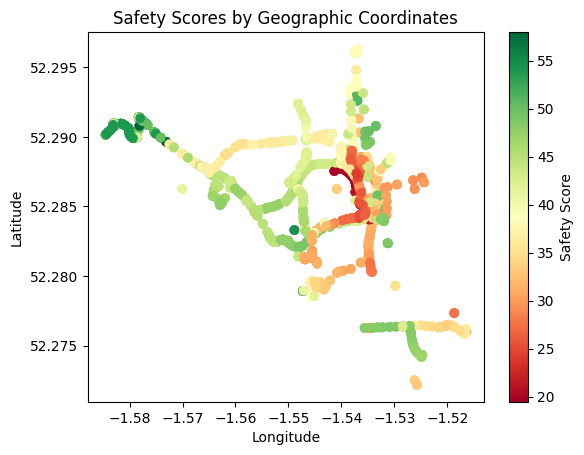

In [35]:
import numpy as np
import matplotlib.pyplot as plt

longitude = X['Longitude']
latitude = X['Latitude']
safety_scores = y    # Safety scores

plt.scatter(longitude, latitude, c=safety_scores, cmap='RdYlGn')
plt.colorbar(label='Safety Score')  # Adds a color bar to interpret the safety score
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Safety Scores by Geographic Coordinates")

plt.show()


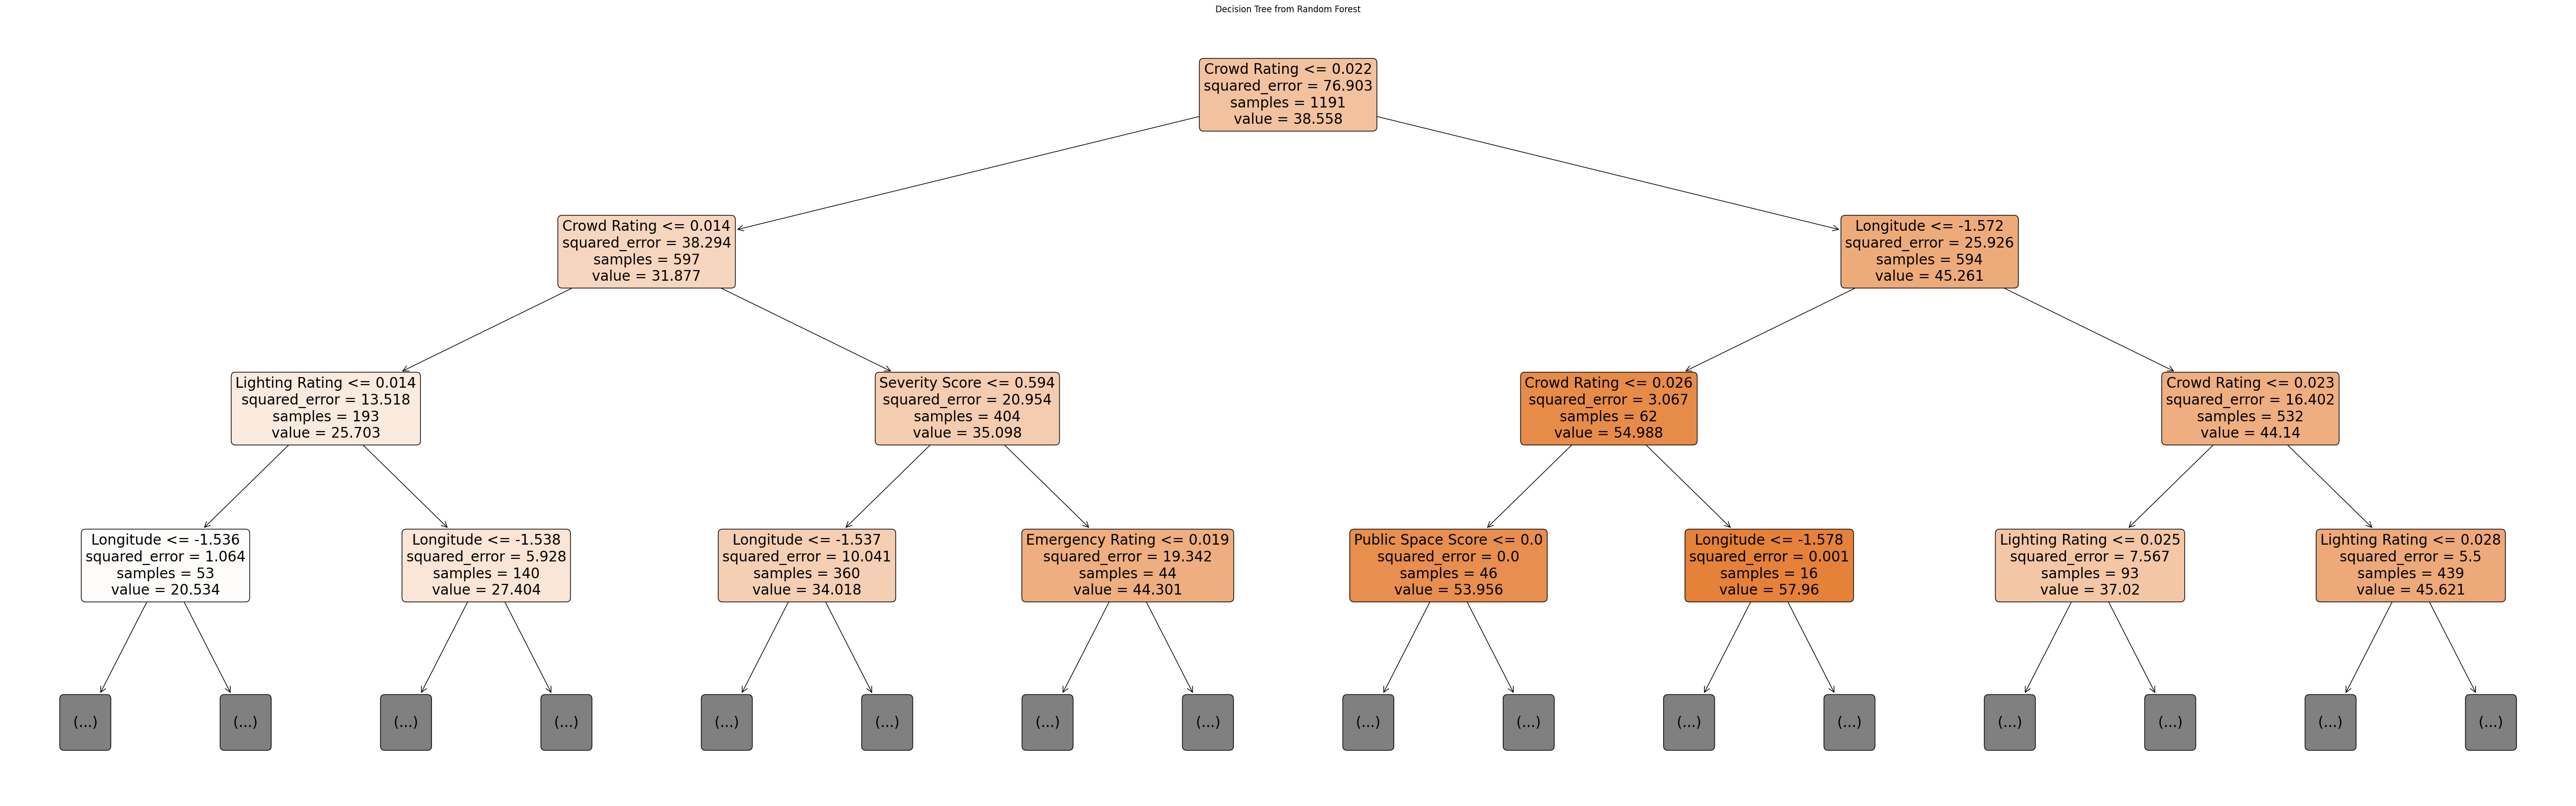

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming regressor is your trained Random Forest model
# Pick one tree from the forest, e.g., the first tree (index 0)
tree_to_plot = regressor.estimators_[5]

# Plot the decision tree
plt.figure(figsize=(65, 20))
plot_tree(tree_to_plot, feature_names=X.columns.tolist(), filled=True, rounded=True, max_depth=3, fontsize=20)
plt.title("Decision Tree from Random Forest")
plt.show()

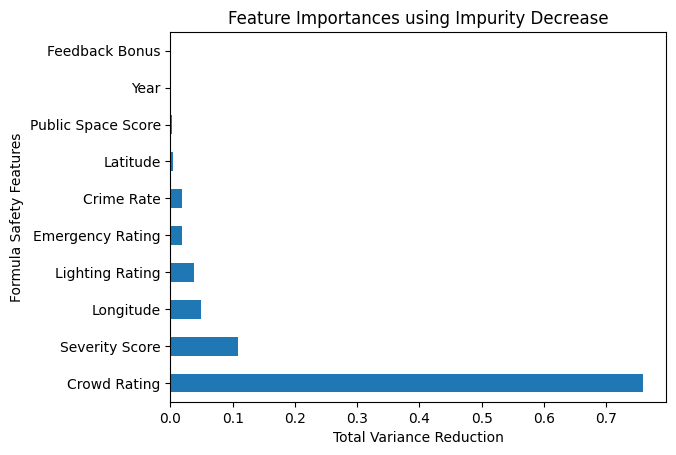

In [37]:
feature_importances = pd.Series(regressor.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')  # Top 10 features
plt.xlabel('Total Variance Reduction')  # Labeling the x-axis with the metric used
plt.ylabel('Formula Safety Features')  # Labeling the y-axis as 'Importance'
plt.title('Feature Importances using Impurity Decrease')  # Adding a title
plt.show()

Text(0.5, 1.0, 'Pie Chart of Feature Importances')

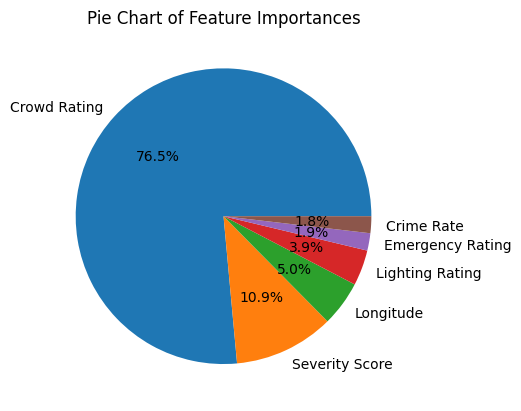

In [38]:
feature_importances.nlargest(6).plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart of Feature Importances')


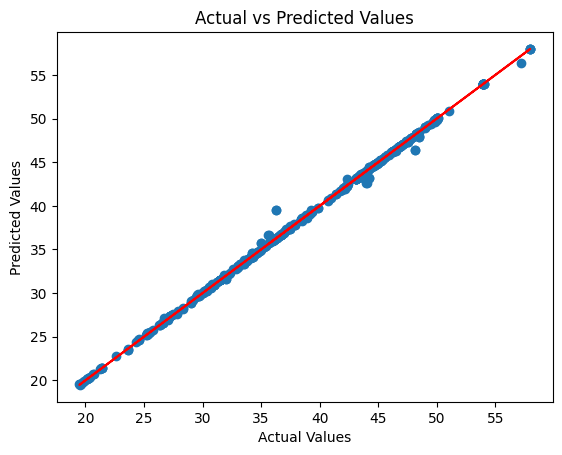

In [39]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs predicted values
plt.scatter(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.plot(y_test, y_test, color='red')  # Line for perfect predictions
plt.show()

In [40]:
from sklearn.inspection import permutation_importance

# Perform permutation feature importance
results = permutation_importance(regressor, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

# Get the importances and standard deviations
importances = results.importances_mean
std_devs = results.importances_std

# Print the feature importances
print("Feature importances:")
for i in range(importances.size):
    print(f"{X_train.columns[i]}: {importances[i]:.3f} +/- {std_devs[i]:.3f}")

forest_importances = pd.Series(results.importances_mean, index=X_train.columns)
forest_importances


Feature importances:
Latitude: 0.002 +/- 0.000
Longitude: 0.027 +/- 0.003
Year: -0.000 +/- 0.000
Lighting Rating: 0.071 +/- 0.003
Crowd Rating: 1.130 +/- 0.073
Emergency Rating: 0.050 +/- 0.006
Crime Rate: 0.005 +/- 0.000
Severity Score: 0.202 +/- 0.019
Public Space Score: 0.004 +/- 0.000
Feedback Bonus: 0.000 +/- 0.000


Latitude              0.002222
Longitude             0.027150
Year                 -0.000003
Lighting Rating       0.070672
Crowd Rating          1.130077
Emergency Rating      0.050400
Crime Rate            0.004850
Severity Score        0.201790
Public Space Score    0.003745
Feedback Bonus        0.000000
dtype: float64

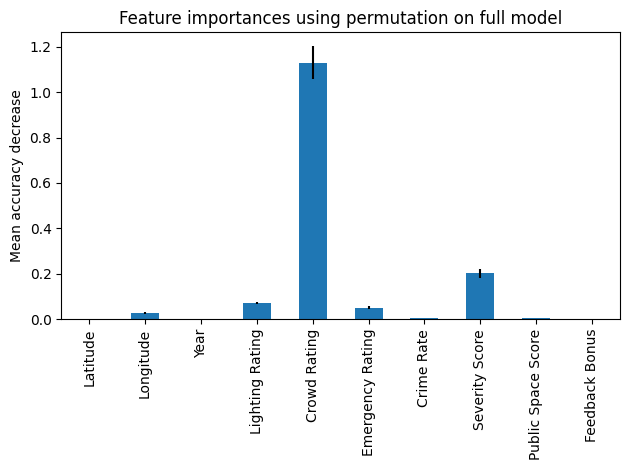

In [41]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=results.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

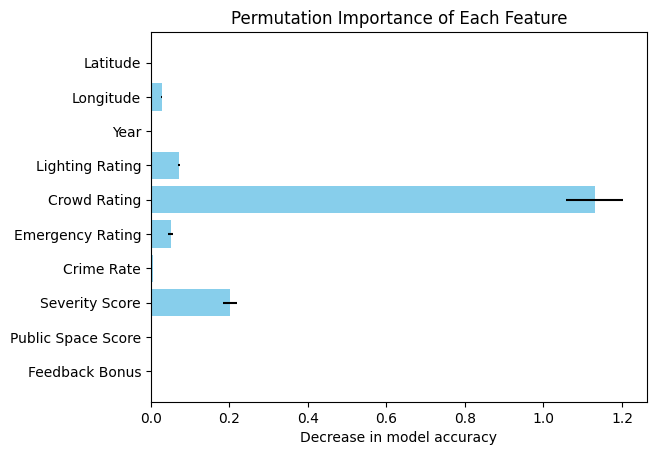

In [42]:
# Calculate permutation importance
perm_importance = permutation_importance(regressor, X_test, y_test, n_repeats=10, random_state=42)

# Get importance scores
importances = perm_importance.importances_mean
std_devs = perm_importance.importances_std
features = X_test.columns

# Plot feature importance
plt.barh(features, importances, xerr=std_devs, align='center', color='skyblue')
plt.xlabel('Decrease in model accuracy')
plt.title('Permutation Importance of Each Feature')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important features on top
plt.show()

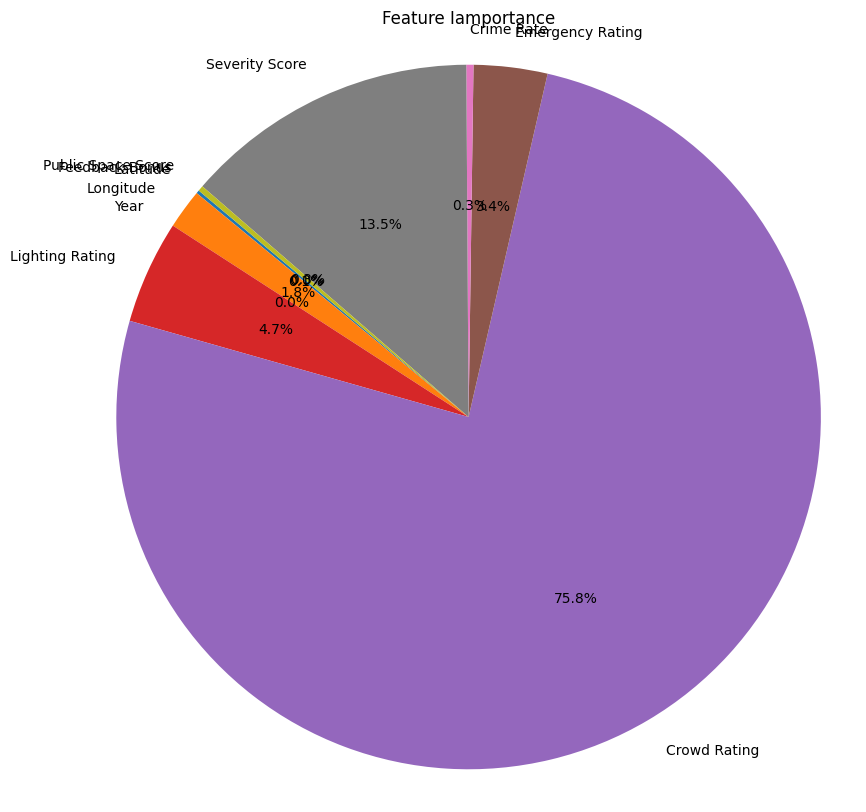

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Convert importances to absolute values
importances_abs = np.abs(importances)

# Normalize the importance values so they sum to 1
importances_normalized = importances_abs / importances_abs.sum()

# Ensure you have the correct feature names array 'features'
plt.figure(figsize=(10, 10))
plt.pie(importances_normalized, labels=features, autopct='%1.1f%%', startangle=140)
plt.title('Feature Iamportance')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
